<a href="https://colab.research.google.com/github/mgb1112/Data-Science-For-Public-Health/blob/main/hw3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
!pip install adjustText

Telencephalon_L_volume: 467063
Telencephalon_R_volume: 470488
ICV_fraction: 0.7845516583473847
TBV_fraction: 0.8348063710737297
   type  level  total_volume
0     1      1       1195015
1     1      2       1195021
2     1      3       1195034
3     1      4       1195065
4     1      5       1195124


<ipython-input-42-8e9a547b8d12>:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type1_level2_df, x="roi", y="volume", palette="viridis")


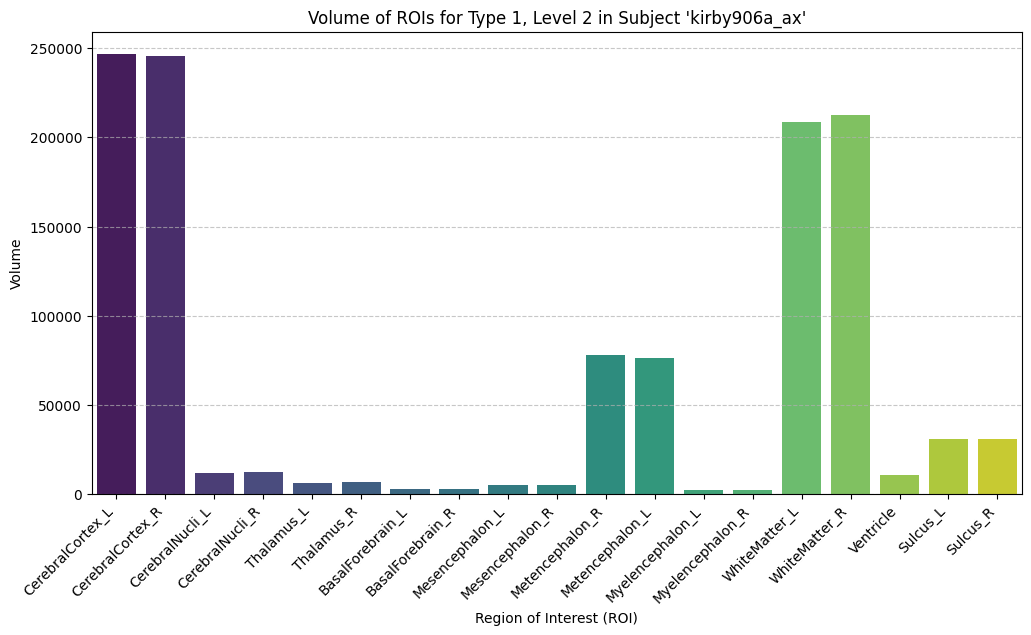

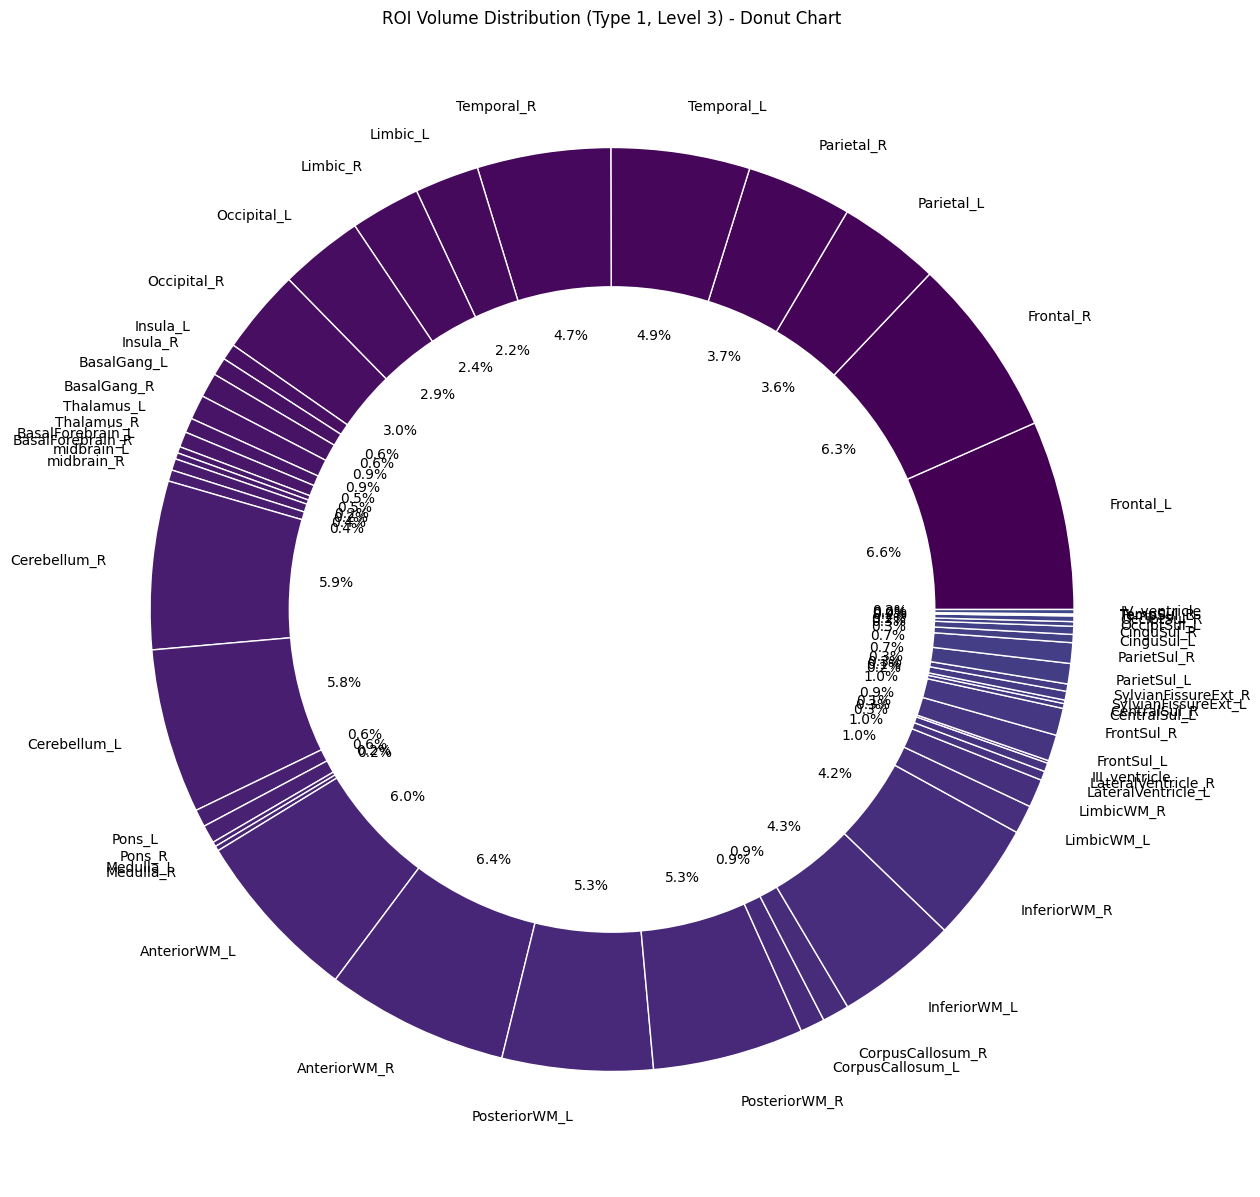

In [ ]:
## use pd.read_csv to import the rawdata
kirb21_df = pd.read_csv("https://raw.githubusercontent.com/smart-stats/ds4bio_book/main/book/assetts/kirby21AllLevels.csv")

## create dataset from the proper subset of the data
kirby906a_ax_df = kirb21_df[kirb21_df["rawid"] == "kirby906a_ax.img"]

## view the dataset we just created
kirby906a_ax_df

## volume calculations of the left and right telencephalon
telencephalon_L_volume = kirby906a_ax_df[kirby906a_ax_df["roi"] == "Telencephalon_L"][
    "volume"
].sum()
telencephalon_R_volume = kirby906a_ax_df[kirby906a_ax_df["roi"] == "Telencephalon_R"][
    "volume"
].sum()
## print only the calculated volumes
print("Telencephalon_L_volume:", telencephalon_L_volume)
print("Telencephalon_R_volume:", telencephalon_R_volume)
## calculate the ICV and TBV
icv = kirby906a_ax_df["icv"].iloc[0] if not kirby906a_ax_df["icv"].isna().all() else None
tbv = kirby906a_ax_df["tbv"].iloc[0] if not kirby906a_ax_df["tbv"].isna().all() else None
## calculate the fractions of the ICV and TBV made up by the telencephalon
icv_fraction = (telencephalon_L_volume + telencephalon_R_volume) / icv
tbv_fraction = (telencephalon_L_volume + telencephalon_R_volume) / tbv
## print the fractions
print("ICV_fraction:", icv_fraction)
print("TBV_fraction:", tbv_fraction)

## group by 'type' and 'level' and sum the 'volume'
all_regions_df = kirby906a_ax_df.groupby(["type", "level"])["volume"].sum().reset_index()
## rename the summed column
all_regions_df.rename(columns={"volume": "total_volume"}, inplace=True)
## print a preview of the data frame
print(all_regions_df.head())

## filter data for this subject with Type 1, Level 2
type1_level2_df = kirby906a_ax_df[(kirby906a_ax_df["type"] == 1) & (kirby906a_ax_df["level"] == 2)]
## create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(data=type1_level2_df, x="roi", y="volume", palette="viridis")
## customize the plot
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for readability
plt.xlabel("Region of Interest (ROI)")
plt.ylabel("Volume")
plt.title("Volume of ROIs for Type 1, Level 2 in Subject 'kirby906a_ax'")
plt.grid(axis="y", linestyle="--", alpha=0.7)
## show the plot
plt.show()

## filter for specific subject and Type 1, Level 3
type1_level3_df = kirby906a_ax_df[(kirby906a_ax_df["type"] == 1) & (kirby906a_ax_df["level"] == 3)]
## extract ROI labels and volumes
roi_labels = type1_level3_df["roi"]
volumes = type1_level3_df["volume"]
## create donut chart
plt.figure(figsize=(15, 15))
colors = plt.cm.viridis(range(len(roi_labels)))  # Generate color map
plt.pie(volumes, labels=roi_labels, autopct='%1.1f%%', colors=colors, wedgeprops={'edgecolor': 'white'})
## add a circle in the center to create a "donut"
center_circle = plt.Circle((0, 0), 0.7, fc='white')
plt.gca().add_artist(center_circle)
## add title
plt.title("ROI Volume Distribution (Type 1, Level 3) - Donut Chart")
## show plot
plt.show()


       Year           Program
0  Master's               BME
1  Master's               BME
2    Senior               BME
3       PhD               BME
4       PhD  Computer_Science


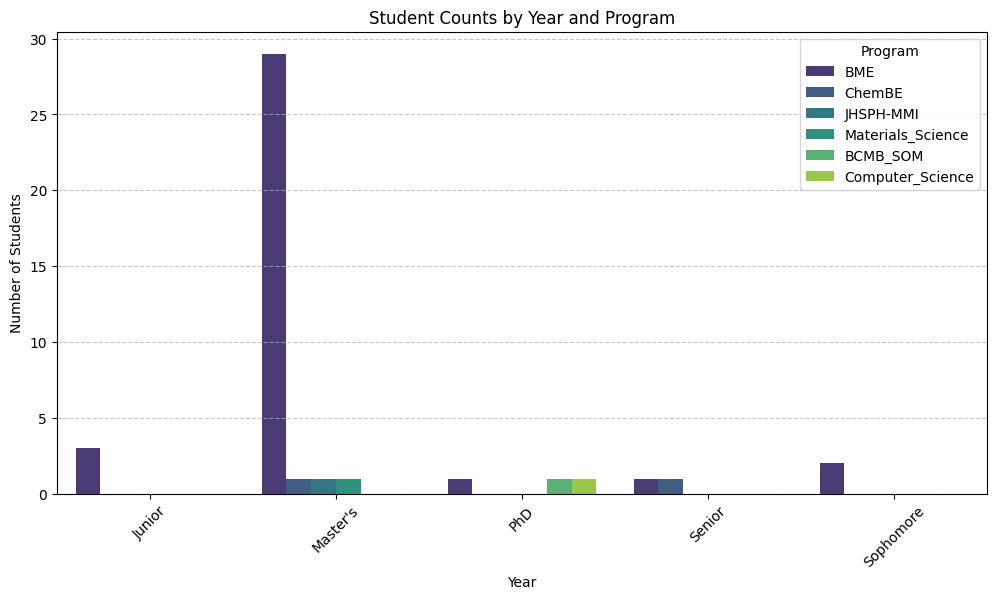

In [ ]:
## load dataset from GitHub
url = "https://raw.githubusercontent.com/bcaffo/ds4bme/master/data/classInterests.txt"
class_interests_df = pd.read_csv(url, sep="\t")
## preview data
print(class_interests_df.head())
## count students by 'year' and 'program'
year_program_counts = class_interests_df.groupby(["Year", "Program"]).size().reset_index(name="count")
## plot using Seaborn
plt.figure(figsize=(12, 6))
sns.barplot(data=year_program_counts, x="Year", y="count", hue="Program", palette="viridis")
## add customization to plot
plt.xlabel("Year")
plt.ylabel("Number of Students")
plt.title("Student Counts by Year and Program")
plt.xticks(rotation=45)
plt.legend(title="Program")
plt.grid(axis="y", linestyle="--", alpha=0.7)
## show the plot
plt.show()

In [ ]:
## load gene expression dataset
url = "https://raw.githubusercontent.com/jhu-advdatasci/2018/refs/heads/master/data/GSE5859_exprs.csv"
gene_expression_df = pd.read_csv(url, index_col=0)  # Assuming first column is gene names
## subtract the row mean from each row
row_means = gene_expression_df.mean(axis=1)  # Compute row means
gene_expression_df_pt1 = gene_expression_df.sub(row_means, axis=0)  # Subtract row means
## subtract the column mean from each column
col_means = gene_expression_df_pt1.mean(axis=0)  # Compute column means
gene_expression_df_pt2 = gene_expression_df_pt1.sub(col_means, axis=1)  # Subtract column means
## normalize each column by standard deviation
col_std = gene_expression_df_pt2.std(axis=0)  # Compute column standard deviations
gene_expression_df_pt3 = gene_expression_df_pt2.div(col_std, axis=1)  # Divide each column by its std dev
## display the first few rows of the final normalized dataset
print(gene_expression_df_pt3.head())


           GSM25581.CEL.gz  GSM25681.CEL.gz  GSM136524.CEL.gz  \
1007_s_at        -0.062810        -1.694428         -0.797346   
1053_at           0.484259         0.835005          1.434085   
117_at            0.789673        -1.707110         -1.548943   
121_at           -1.599798        -1.460817         -0.134750   
1255_g_at         1.090032        -0.216675         -0.238137   

           GSM136707.CEL.gz  GSM25553.CEL.gz  GSM136676.CEL.gz  \
1007_s_at          0.362538        -1.152413          0.366177   
1053_at           -0.316432         0.141554         -0.076237   
117_at            -0.245036        -1.015618         -0.637799   
121_at             1.138467        -1.255766          1.368016   
1255_g_at          0.480868        -0.479461         -0.082265   

           GSM136711.CEL.gz  GSM136542.CEL.gz  GSM136535.CEL.gz  \
1007_s_at          1.252187         -0.054154          1.008166   
1053_at           -0.745136         -0.148166         -0.250652   
117_at     

           State  Year  Spending
0  United States  1991  675896.0
1        Alabama  1991   10393.0
2         Alaska  1991    1458.0
3        Arizona  1991    9269.0
4       Arkansas  1991    5632.0


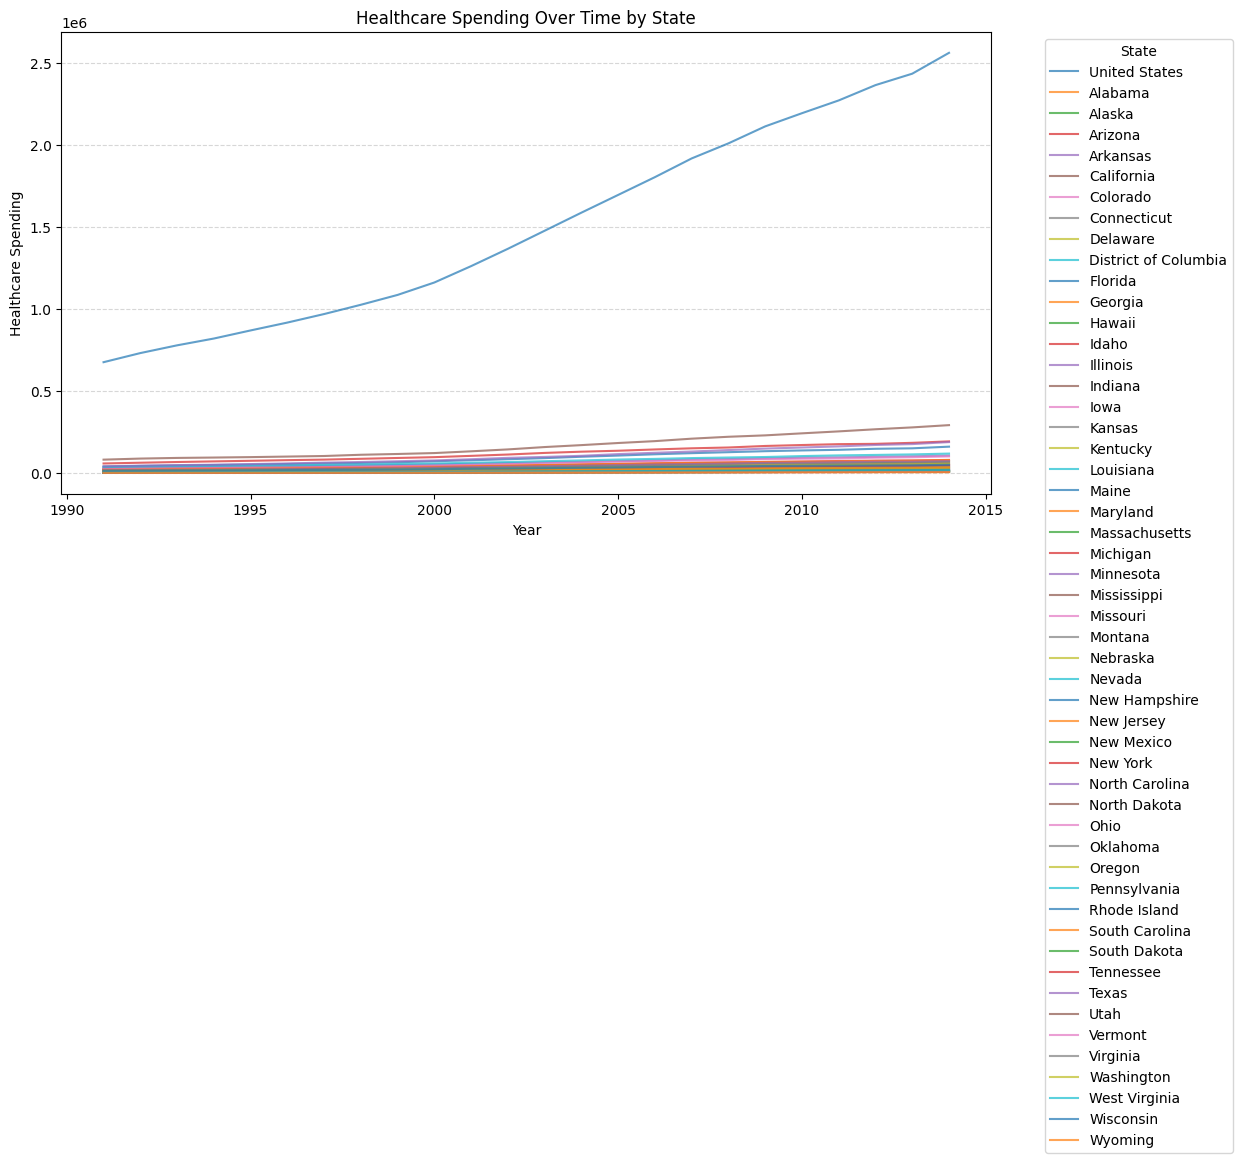

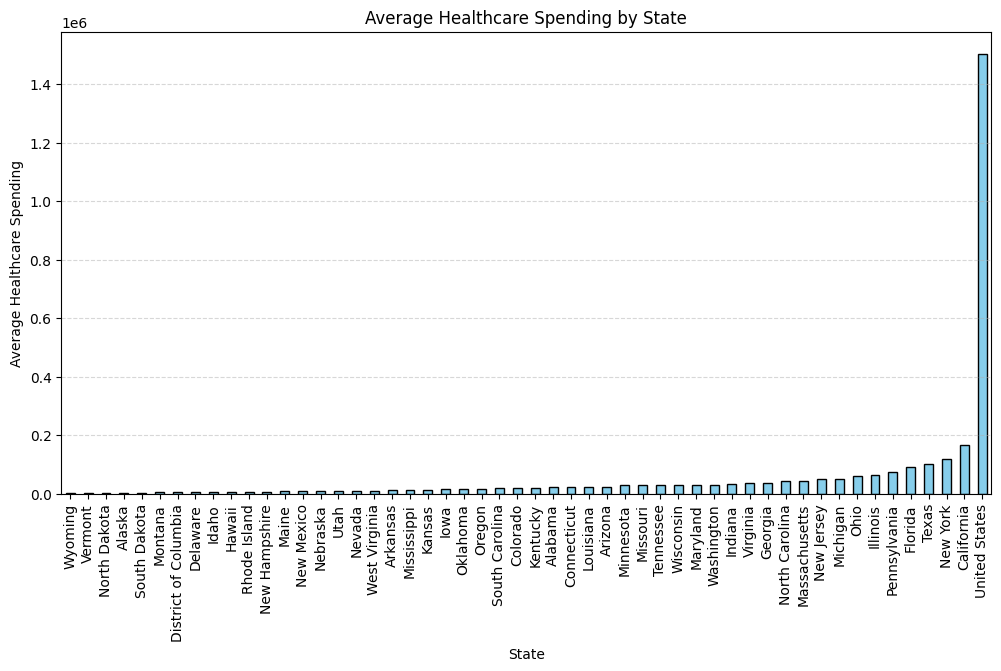

In [ ]:
## load healthcare dataset (skip first two metadata rows)
url = "https://raw.githubusercontent.com/jhu-advdatasci/2018/master/data/KFF/healthcare-spending.csv"
healthcare_df = pd.read_csv(url, skiprows=2)
## rename "Location" to "State"
healthcare_df.rename(columns={"Location": "State"}, inplace=True)
healthcare_df_clean = healthcare_df.drop(healthcare_df.index[52:64])
## convert wide format to long format
healthcare_long_df = healthcare_df_clean.melt(id_vars=["State"],
                                        var_name="Year",
                                        value_name="Spending")
## remove extra text in "Year" column
healthcare_long_df["Year"] = healthcare_long_df["Year"].str.extract(r"(\d{4})").astype(int)
## convert "Spending" to numeric (some values might be strings)
healthcare_long_df["Spending"] = pd.to_numeric(healthcare_long_df["Spending"], errors="coerce")
## preview clean data
print(healthcare_long_df.head())

## create plot: Healthcare Spending Over Time by State
plt.figure(figsize=(12, 6))
sns.lineplot(data=healthcare_long_df, x="Year", y="Spending", hue="State", palette="tab10", alpha=0.7)
plt.xlabel("Year")
plt.ylabel("Healthcare Spending")
plt.title("Healthcare Spending Over Time by State")
plt.legend(title="State", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## compute average healthcare spending per state
avg_spending_per_state = healthcare_long_df.groupby("State")["Spending"].mean().sort_values()
## create bar plot of average healthcare spending by state
plt.figure(figsize=(12, 6))
avg_spending_per_state.plot(kind="bar", color="skyblue", edgecolor="black")
plt.xlabel("State")
plt.ylabel("Average Healthcare Spending")
plt.title("Average Healthcare Spending by State")
plt.xticks(rotation=90)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()